# Notebook de Análisis de Datos Preliminar
## Semillero de Investigación 2026

Este notebook realiza la **exploración y análisis preliminar** del dataset [High-Throughput Algae Cell Detection](https://www.kaggle.com/datasets/marquis03/high-throughput-algae-cell-detection) (Kaggle: marquis03).

El dataset contiene imágenes microscópicas de células de algas anotadas para detección de objetos en formato YOLO. Se siguen los mismos pasos que en el análisis del dataset de Espirulina: importación de librerías, exploración de la estructura, construcción de un DataFrame de anotaciones, análisis visual preliminar y limpieza de datos.

## 0. Preparación del Dataset (Kaggle -> ruta estándar del proyecto)

Esta sección deja el dataset en la ruta fija del repositorio:
`nuevo-dataset/high-throughput-algae-cell-detection`

### Requisitos previos para todos los integrantes
1. Tener cuenta de Kaggle y aceptar las reglas del dataset.
2. Instalar dependencia: `pip install kagglehub`.
3. Configurar credenciales de Kaggle:
   - Opción A (recomendada): archivo `kaggle.json` en `%USERPROFILE%/.kaggle/` (Windows) o `~/.kaggle/` (Linux/Mac).
   - Opción B: variables de entorno `KAGGLE_USERNAME` y `KAGGLE_KEY`.
4. Tener conexión a internet y acceso a `api.kaggle.com`.

Si no hay conexión o falla DNS, descarga el dataset manualmente desde Kaggle y colócalo en:
`nuevo-dataset/high-throughput-algae-cell-detection`

La celda de abajo es idempotente: si la carpeta ya existe y tiene contenido, no vuelve a descargar.

In [1]:
from pathlib import Path
import shutil

# Ruta objetivo estándar para todo el equipo (dentro del repositorio)
repo_root = Path.cwd()
target_dir = repo_root / "nuevo-dataset" / "high-throughput-algae-cell-detection"
dataset_slug = "marquis03/high-throughput-algae-cell-detection"

target_dir.parent.mkdir(parents=True, exist_ok=True)

if target_dir.exists() and any(target_dir.iterdir()):
    print(f"Dataset ya disponible en: {target_dir.resolve()}")
else:
    try:
        import kagglehub
    except ImportError as e:
        raise ImportError(
            "No se encontró 'kagglehub'. Instala con: pip install kagglehub"
        ) from e

    print("Descargando dataset desde Kaggle... (puede tardar varios minutos)")
    try:
        downloaded_path = Path(kagglehub.dataset_download(dataset_slug))
        print(f"Descarga completada en caché: {downloaded_path.resolve()}")

        # Copiar al destino del proyecto para mantener una ruta común en todos los equipos
        if target_dir.exists():
            shutil.rmtree(target_dir)
        shutil.copytree(downloaded_path, target_dir)

        print(f"Dataset copiado a ruta estándar: {target_dir.resolve()}")
    except Exception as e:
        print("\nNo fue posible descargar automáticamente desde Kaggle.")
        print(f"Detalle técnico: {type(e).__name__}: {e}")
        print("\nAcción manual requerida:")
        print("1) Descarga el dataset desde Kaggle en otro entorno con internet.")
        print("2) Copia la carpeta resultante en:")
        print(f"   {target_dir.resolve()}")
        print("3) Vuelve a ejecutar esta celda.")
        raise RuntimeError(
            "Fallo la descarga automática. Revisa internet/DNS o usa la carga manual en la ruta indicada."
        ) from e

print("Listo. Continúa con la siguiente celda del notebook.")

d:\Documentos\Universidad\4to Semestre Ingeniería\Opción de Grado - Investigación\semillero-de-investigacion-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando dataset desde Kaggle... (puede tardar varios minutos)
Descarga completada en caché: C:\Users\Rinco\.cache\kagglehub\datasets\marquis03\high-throughput-algae-cell-detection\versions\3
Dataset copiado a ruta estándar: D:\Documentos\Universidad\4to Semestre Ingeniería\Opción de Grado - Investigación\semillero-de-investigacion-2026\nuevo-dataset\high-throughput-algae-cell-detection
Listo. Continúa con la siguiente celda del notebook.


In [2]:
from pathlib import Path

# Usar dataset local oficial (ya descargado y pegado en el proyecto)
project_root = Path.cwd()
candidate_paths = [
    project_root / 'high-throughput-algae-cell-detection' / 'versions' / '3',
    project_root / 'nuevo-dataset' / 'high-throughput-algae-cell-detection' / 'versions' / '3',
    project_root / 'high-throughput-algae-cell-detection',
    project_root / 'nuevo-dataset' / 'high-throughput-algae-cell-detection',
]

dataset_root = next((p for p in candidate_paths if p.exists()), None)
if dataset_root is None:
    raise FileNotFoundError(
        'No se encontró el dataset local high-throughput-algae-cell-detection en las rutas esperadas.'
    )

path = str(dataset_root.resolve())
print('Path to dataset files:', path)

Path to dataset files: D:\Documentos\Universidad\4to Semestre Ingeniería\Opción de Grado - Investigación\semillero-de-investigacion-2026\nuevo-dataset\high-throughput-algae-cell-detection


## 1. Importación de Librerías Básicas

In [3]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Librerías para manejo de archivos y rutas
import os
import glob
from pathlib import Path

# Librería para imágenes
from PIL import Image

# Configuración de warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas exitosamente")

Librerías importadas exitosamente


## 2. Configuración de Visualización

In [4]:
# Configuración de matplotlib
%matplotlib inline

# Configurar estilo de gráficas (con manejo de compatibilidad)
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuración de seaborn
sns.set_palette('husl')

print("Configuración de visualización aplicada")

Configuración de visualización aplicada


## 3. Configuración de Pandas

In [5]:
# Opciones de visualización de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Configuración de pandas aplicada")

Configuración de pandas aplicada


## 4. Verificación de Versiones

In [6]:
# Verificar versiones de las librerías
import matplotlib
from PIL import __version__ as pil_version

print(f"Pandas version:     {pd.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version:    {sns.__version__}")
print(f"Pillow version:     {pil_version}")

Pandas version:     3.0.1
NumPy version:      2.4.3
Matplotlib version: 3.10.8
Seaborn version:    0.13.2
Pillow version:     12.1.1


## 5. Exploración de la Estructura del Dataset

Exploración del árbol de directorios y conteo de archivos por tipo del dataset local oficial.

In [7]:
# Usar la ruta local del dataset
dataset_path = Path(path)

print(f"📂 Ruta del dataset: {dataset_path}\n")

# Contar archivos por extensión
extensions = {}
total_files = 0
for item in dataset_path.rglob('*'):
    if item.is_file():
        ext = item.suffix.lower()
        extensions[ext] = extensions.get(ext, 0) + 1
        total_files += 1

print(f"📊 Total de archivos: {total_files:,}")
print("\n📂 Archivos por extensión:")
for ext, count in sorted(extensions.items(), key=lambda x: -x[1]):
    print(f"   {ext or '(sin extensión)':20s}: {count:,}")

# Mostrar estructura de directorios (2 niveles)
print("\n📁 Estructura de directorios:")
for item in sorted(dataset_path.iterdir()):
    if item.is_dir():
        n_files = len(list(item.rglob('*.*')))
        print(f"   📁 {item.name}/  ({n_files} archivos)")
        for sub in sorted(item.iterdir()):
            if sub.is_dir():
                n_sub = len(list(sub.rglob('*.*')))
                print(f"      📁 {sub.name}/  ({n_sub} archivos)")
            else:
                print(f"      📄 {sub.name}")
    else:
        print(f"   📄 {item.name}")

📂 Ruta del dataset: D:\Documentos\Universidad\4to Semestre Ingeniería\Opción de Grado - Investigación\semillero-de-investigacion-2026\nuevo-dataset\high-throughput-algae-cell-detection

📊 Total de archivos: 2,002

📂 Archivos por extensión:
   .jpg                : 1,000
   .txt                : 1,000
   .yaml               : 1
   .md                 : 1

📁 Estructura de directorios:
   📄 data.yaml
   📁 test/  (600 archivos)
      📁 test/  (600 archivos)
   📁 train/  (1401 archivos)
      📁 train/  (1401 archivos)


## 6. Carga de Configuración y Clases

El formato YOLO incluye un archivo `.yaml` con metadatos del dataset: número de clases (`nc`), nombres de clases (`names`) y rutas de splits.

In [8]:
import yaml

# Buscar archivo YAML de configuración
yaml_files = list(dataset_path.rglob('*.yaml')) + list(dataset_path.rglob('*.yml'))

classes = []
nc = 0
config = {}

if yaml_files:
    yaml_path = yaml_files[0]
    print(f"✅ Archivo de configuración encontrado: {yaml_path.name}\n")
    with open(yaml_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)

    print("📋 Configuración del dataset:")
    for key, val in config.items():
        print(f"   {key}: {val}")

    classes = config.get('names', [])
    nc = config.get('nc', len(classes))

    print(f"\n🔬 Número de clases: {nc}")
    print("🏷️  Clases detectadas:")
    for i, cls in enumerate(classes):
        print(f"   [{i}] {cls}")
else:
    print("⚠️  No se encontró archivo YAML. Las clases se inferirán desde las anotaciones.")

✅ Archivo de configuración encontrado: data.yaml

📋 Configuración del dataset:
   train: ../train/images
   val: ../train/images
   test: ../test
   nc: 6
   names: ['Platymonas', 'Chlorella', 'Dunaliella salina', 'Effrenium', 'Porphyridium', 'Haematococcus']

🔬 Número de clases: 6
🏷️  Clases detectadas:
   [0] Platymonas
   [1] Chlorella
   [2] Dunaliella salina
   [3] Effrenium
   [4] Porphyridium
   [5] Haematococcus


# Buscar cualquier carpeta 'labels' con archivos .txt y emparejarla con su carpeta 'images' hermana
label_dirs = [d for d in dataset_path.rglob('labels') if d.is_dir()]

for lbl_dir in label_dirs:
    label_files = list(lbl_dir.glob('*.txt'))
    if not label_files:
        continue

    parent_dir = lbl_dir.parent
    img_dir = parent_dir / 'images'
    if not img_dir.exists():
        continue

    raw_split = parent_dir.name.lower()
    split = 'val' if raw_split in {'valid', 'validation'} else raw_split

    # Si hay duplicados del mismo split, conservar el que tenga más imágenes
    n_imgs = len(list(img_dir.glob('*.*')))
    prev = split_paths.get(split)
    if (prev is None) or (n_imgs > prev['n_images']):
        split_paths[split] = {'images': img_dir, 'labels': lbl_dir, 'n_images': n_imgs}

splits_found = sorted(split_paths.keys())
| `y_center` | Coordenada Y del centro (normalizada 0-1) |
| `width` | Ancho del bounding box (normalizado 0-1) |
| `height` | Alto del bounding box (normalizado 0-1) |
| `area` | Área del bounding box (`width × height`) |
| `aspect_ratio` | Relación de aspecto (`width / height`) |

In [9]:
# Identificar splits disponibles con sus rutas de imágenes y etiquetas
splits_found = []
split_paths = {}

# Buscar cualquier carpeta 'labels' y emparejarla con su carpeta 'images' hermana
label_dirs = [d for d in dataset_path.rglob('labels') if d.is_dir()]

for lbl_dir in label_dirs:
    label_files = [f for f in lbl_dir.glob('*') if f.is_file() and f.suffix.lower() == '.txt']
    if not label_files:
        continue

    parent_dir = lbl_dir.parent
    img_dir = parent_dir / 'images'
    if not img_dir.exists():
        continue

    raw_split = parent_dir.name.lower()
    split = 'val' if raw_split in {'valid', 'validation'} else raw_split

    # Si hay duplicados del mismo split, conservar el que tenga más imágenes
    n_imgs = len([f for f in img_dir.glob('*') if f.is_file()])
    prev = split_paths.get(split)
    if (prev is None) or (n_imgs > prev['n_images']):
        split_paths[split] = {'images': img_dir, 'labels': lbl_dir, 'n_images': n_imgs}

splits_found = sorted(split_paths.keys())

print(f"📂 Splits encontrados: {splits_found}\n")

# Parsear todas las anotaciones YOLO en un DataFrame
records = []
img_counts = {}

for split in splits_found:
    img_dir = split_paths[split]['images']
    lbl_dir = split_paths[split]['labels']

    img_files = [f for f in img_dir.glob('*') if f.is_file()]
    img_counts[split] = len(img_files)

    label_files = [f for f in lbl_dir.glob('*') if f.is_file() and f.suffix.lower() == '.txt']

    for lbl_file in label_files:
        try:
            with open(lbl_file, 'r', encoding='utf-8') as f:
                lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    x_c = float(parts[1])
                    y_c = float(parts[2])
                    w   = float(parts[3])
                    h   = float(parts[4])
                    records.append({
                        'split':        split,
                        'filename':     lbl_file.stem,
                        'class_id':     cls_id,
                        'class_name':   classes[cls_id] if cls_id < len(classes) else f'class_{cls_id}',
                        'x_center':     x_c,
                        'y_center':     y_c,
                        'width':        w,
                        'height':       h,
                        'area':         w * h,
                        'aspect_ratio': w / h if h > 0 else np.nan
                    })
        except Exception as e:
            print(f"⚠️  Error en {lbl_file.name}: {e}")

df = pd.DataFrame(records)
print("✅ DataFrame de anotaciones creado")
print(f"\n📊 Resumen de imágenes y anotaciones por split:")
for split in splits_found:
    anns = len(df[df['split'] == split])
    imgs = img_counts.get(split, 0)
    print(f"   {split:10s}: {imgs:,} imágenes | {anns:,} anotaciones")
print(f"\n📌 Total anotaciones: {len(df):,}")

📂 Splits encontrados: ['test', 'train']

✅ DataFrame de anotaciones creado

📊 Resumen de imágenes y anotaciones por split:
   test      : 300 imágenes | 1,627 anotaciones
   train     : 701 imágenes | 1,758 anotaciones

📌 Total anotaciones: 3,385


In [10]:
# Primeras filas e información general
print("Datos cargados exitosamente")
print(df.head(10))
print(df.info())

Datos cargados exitosamente
  split filename  class_id         class_name  x_center  y_center  width  \
0  test    00701         0         Platymonas    0.3802    0.8925 0.0312   
1  test    00701         1          Chlorella    0.6602    0.4587 0.0120   
2  test    00701         1          Chlorella    0.0107    0.8192 0.0089   
3  test    00701         1          Chlorella    0.3003    0.2746 0.0089   
4  test    00701         1          Chlorella    0.3352    0.2537 0.0078   
5  test    00702         2  Dunaliella salina    0.8240    0.7742 0.0198   
6  test    00702         0         Platymonas    0.3461    0.5350 0.0255   
7  test    00702         1          Chlorella    0.3122    0.5375 0.0120   
8  test    00702         1          Chlorella    0.0198    0.1725 0.0094   
9  test    00702         1          Chlorella    0.4133    0.7867 0.0109   

   height   area  aspect_ratio  
0  0.0400 0.0013        0.7812  
1  0.0192 0.0002        0.6250  
2  0.0150 0.0001        0.5903  
3  

In [11]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())


Estadísticas descriptivas:


,class_id,x_center,y_center,width,height,area,aspect_ratio
count,3385.0000,3385.0000,3385.0000,3385.0000,3385.0000,3385.0000,3385.0000
mean,2.1784,0.4817,0.5228,0.0289,0.0473,0.0018,0.6313
std,1.5057,0.2760,0.2524,0.0188,0.0287,0.0027,0.1954
min,0.0000,0.0057,0.0196,0.0063,0.0117,0.0001,0.1825
25%,1.0000,0.2437,0.3150,0.0163,0.0283,0.0005,0.5430
50%,2.0000,0.4703,0.5246,0.0238,0.0383,0.0009,0.6534
75%,4.0000,0.7055,0.7319,0.0339,0.0609,0.0020,0.7470
max,5.0000,0.9956,0.9879,0.1575,0.2664,0.0326,1.5000


In [12]:
# Datos faltantes
print("\nDatos faltantes por columna:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores faltantes': missing, 'Porcentaje (%)': missing_pct})
print(missing_df[missing_df['Valores faltantes'] > 0])
if missing.sum() == 0:
    print("✅ No hay valores faltantes en el dataset")


Datos faltantes por columna:
Empty DataFrame
Columns: [Valores faltantes, Porcentaje (%)]
Index: []
✅ No hay valores faltantes en el dataset


## 8. Análisis Visual Preliminar de Datos

Exploración de las variables clave del dataset de detección de células de algas mediante visualizaciones científicas.

### 8.1. Distribución de Clases por Split

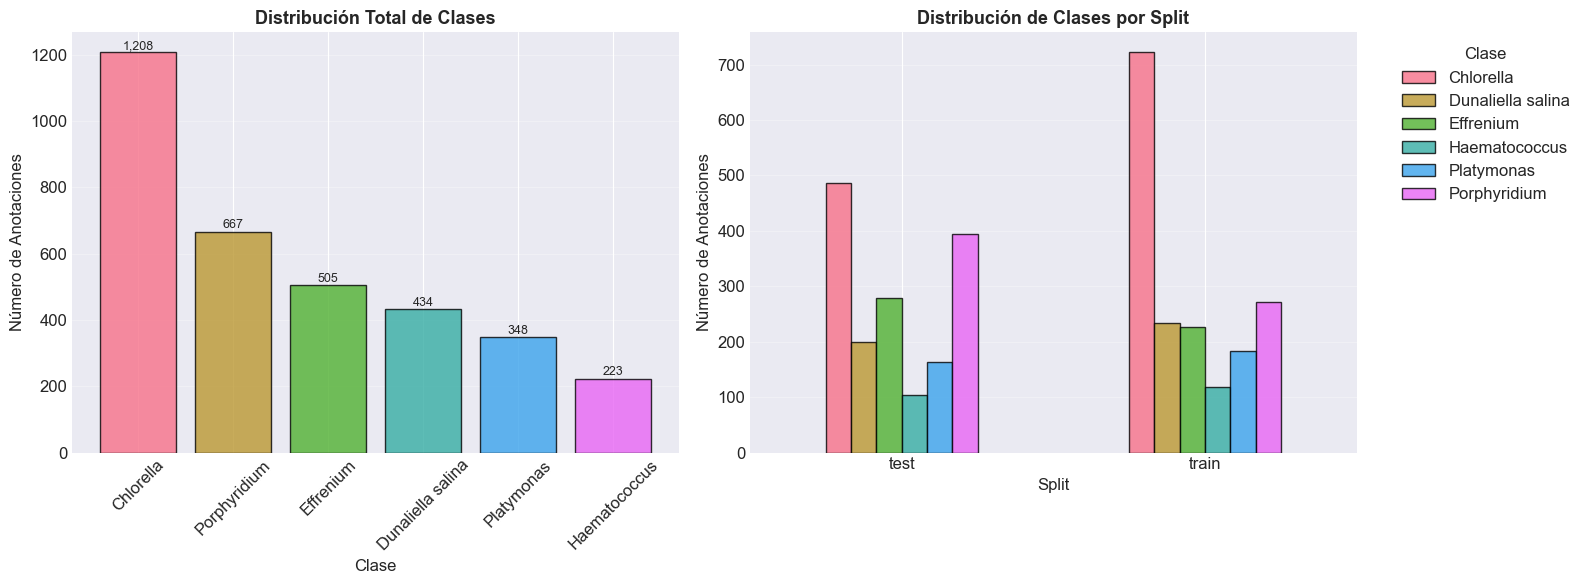


📊 Distribución de clases:
            Clase  Anotaciones
        Chlorella         1208
     Porphyridium          667
        Effrenium          505
Dunaliella salina          434
       Platymonas          348
    Haematococcus          223

   Total: 3,385


In [13]:
# Distribución de clases total y por split
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total por clase
class_counts = df['class_name'].value_counts().reset_index()
class_counts.columns = ['Clase', 'Anotaciones']
colors = sns.color_palette('husl', len(class_counts))

bars = axes[0].bar(class_counts['Clase'], class_counts['Anotaciones'],
                   color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución Total de Clases', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de Anotaciones')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, class_counts['Anotaciones']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Por clase y split
pivot_data = df.groupby(['split', 'class_name']).size().unstack(fill_value=0)
pivot_data.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.8)
axes[1].set_title('Distribución de Clases por Split', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Número de Anotaciones')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Clase', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Distribución de clases:")
print(class_counts.to_string(index=False))
print(f"\n   Total: {class_counts['Anotaciones'].sum():,}")

### 8.2. Distribuciones de Dimensiones de Bounding Boxes

Análisis de la distribución del ancho, alto y área de los bounding boxes (valores normalizados entre 0 y 1).

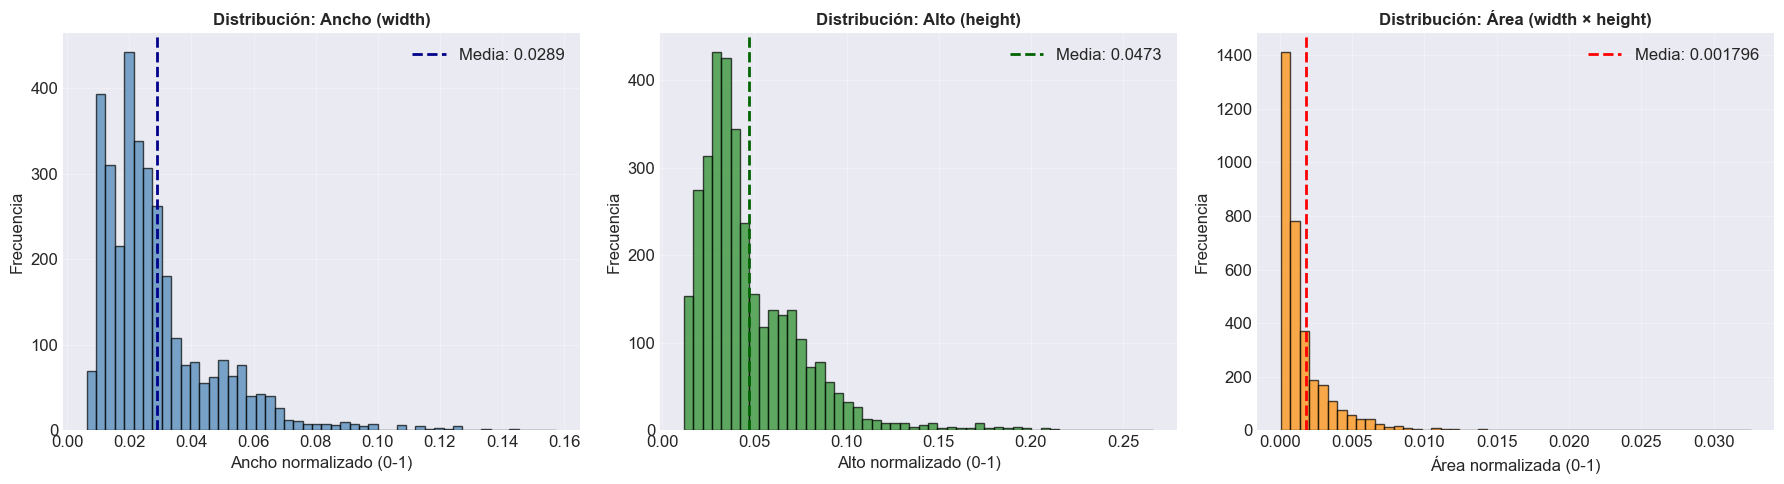


📐 Estadísticas de dimensiones de bounding boxes:
  Ancho  - Media: 0.0289  | Std: 0.0188 | Rango: [0.0063, 0.1575]
  Alto   - Media: 0.0473  | Std: 0.0287 | Rango: [0.0117, 0.2664]
  Área   - Media: 0.001796 | Std: 0.002669 | Rango: [0.000083, 0.032550]


In [14]:
# Histogramas de dimensiones de bounding boxes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ancho (width)
axes[0].hist(df['width'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(df['width'].mean(), color='darkblue', linestyle='--', linewidth=2,
                label=f"Media: {df['width'].mean():.4f}")
axes[0].set_title('Distribución: Ancho (width)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ancho normalizado (0-1)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Alto (height)
axes[1].hist(df['height'], bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
axes[1].axvline(df['height'].mean(), color='darkgreen', linestyle='--', linewidth=2,
                label=f"Media: {df['height'].mean():.4f}")
axes[1].set_title('Distribución: Alto (height)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Alto normalizado (0-1)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Área
axes[2].hist(df['area'], bins=50, color='darkorange', alpha=0.7, edgecolor='black')
axes[2].axvline(df['area'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Media: {df['area'].mean():.6f}")
axes[2].set_title('Distribución: Área (width × height)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Área normalizada (0-1)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📐 Estadísticas de dimensiones de bounding boxes:")
print(f"  Ancho  - Media: {df['width'].mean():.4f}  | Std: {df['width'].std():.4f} | Rango: [{df['width'].min():.4f}, {df['width'].max():.4f}]")
print(f"  Alto   - Media: {df['height'].mean():.4f}  | Std: {df['height'].std():.4f} | Rango: [{df['height'].min():.4f}, {df['height'].max():.4f}]")
print(f"  Área   - Media: {df['area'].mean():.6f} | Std: {df['area'].std():.6f} | Rango: [{df['area'].min():.6f}, {df['area'].max():.6f}]")

### 8.3. Distribución Espacial de los Centros de Celdas

Análisis de dónde tienden a ubicarse las células detectadas dentro de las imágenes. Un patrón uniforme puede indicar cobertura homogénea del microscopio; un patrón concentrado puede indicar sesgo en la captura.

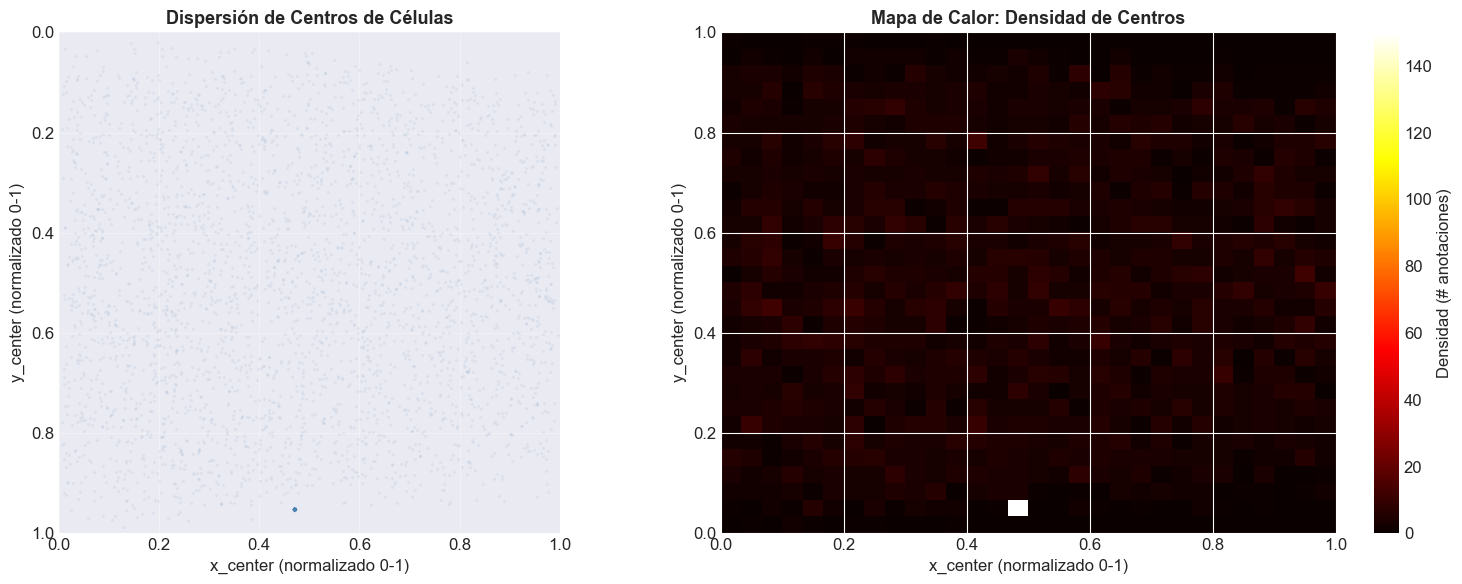


📍 Estadísticas de posición de los centros:
  x_center - Media: 0.4817 | Std: 0.2760 | Rango: [0.0057, 0.9956]
  y_center - Media: 0.5228 | Std: 0.2524 | Rango: [0.0196, 0.9879]


In [15]:
# Distribución espacial de centros de bounding boxes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nube de puntos de centros
axes[0].scatter(df['x_center'], df['y_center'], alpha=0.05, s=2, c='steelblue')
axes[0].set_title('Dispersión de Centros de Células', fontsize=13, fontweight='bold')
axes[0].set_xlabel('x_center (normalizado 0-1)')
axes[0].set_ylabel('y_center (normalizado 0-1)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()  # Alinear con sistema de coordenadas de imagen

# Mapa de calor 2D de densidad
h, xedges, yedges = np.histogram2d(df['x_center'], df['y_center'], bins=30, range=[[0,1],[0,1]])
im = axes[1].imshow(h.T, origin='upper', cmap='hot', extent=[0, 1, 0, 1], aspect='auto')
axes[1].set_title('Mapa de Calor: Densidad de Centros', fontsize=13, fontweight='bold')
axes[1].set_xlabel('x_center (normalizado 0-1)')
axes[1].set_ylabel('y_center (normalizado 0-1)')
plt.colorbar(im, ax=axes[1], label='Densidad (# anotaciones)')

plt.tight_layout()
plt.show()

print(f"\n📍 Estadísticas de posición de los centros:")
print(f"  x_center - Media: {df['x_center'].mean():.4f} | Std: {df['x_center'].std():.4f} | Rango: [{df['x_center'].min():.4f}, {df['x_center'].max():.4f}]")
print(f"  y_center - Media: {df['y_center'].mean():.4f} | Std: {df['y_center'].std():.4f} | Rango: [{df['y_center'].min():.4f}, {df['y_center'].max():.4f}]")

### 8.4. Número de Anotaciones por Imagen

Distribución de cuántas células se detectan por imagen, indicador de la densidad celular en el dataset.

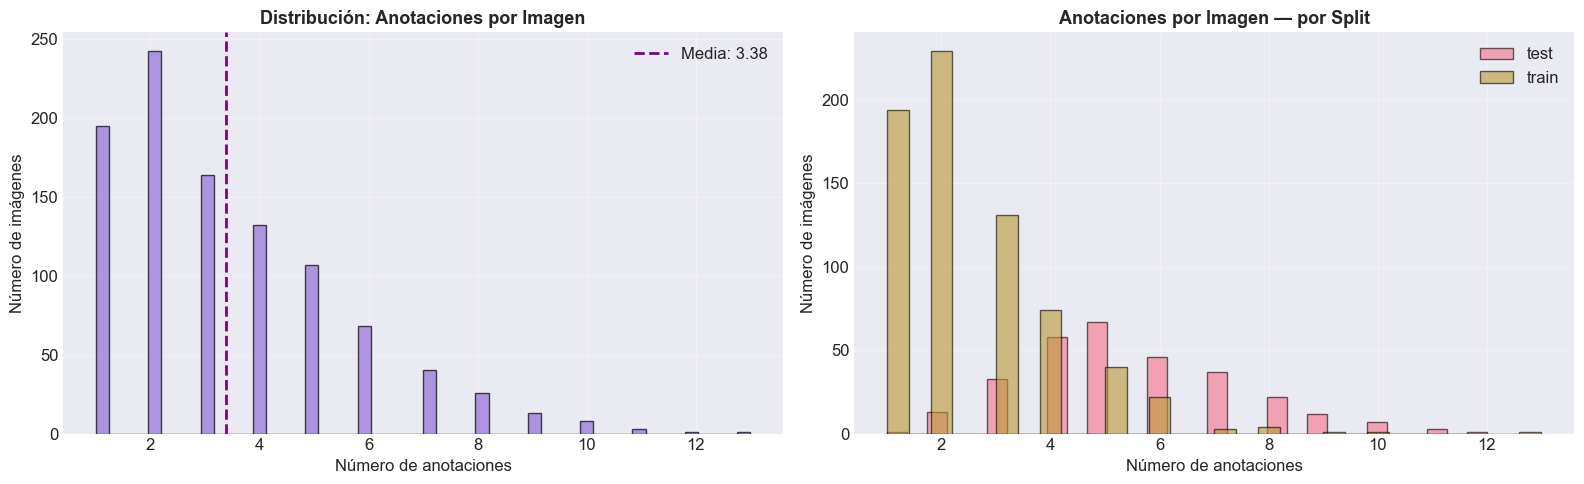


📊 Estadísticas de anotaciones por imagen:
count   1000.0000
mean       3.3800
std        2.1400
min        1.0000
25%        2.0000
50%        3.0000
75%        5.0000
max       13.0000
Name: n_annotations, dtype: float64


In [16]:
# Número de anotaciones por imagen
anns_per_img = df.groupby(['split', 'filename']).size().reset_index(name='n_annotations')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma general
axes[0].hist(anns_per_img['n_annotations'], bins=50, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[0].axvline(anns_per_img['n_annotations'].mean(), color='purple', linestyle='--', linewidth=2,
                label=f"Media: {anns_per_img['n_annotations'].mean():.2f}")
axes[0].set_title('Distribución: Anotaciones por Imagen', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de anotaciones')
axes[0].set_ylabel('Número de imágenes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Por split
for split in anns_per_img['split'].unique():
    subset = anns_per_img[anns_per_img['split'] == split]['n_annotations']
    axes[1].hist(subset, bins=30, alpha=0.6, edgecolor='black', label=split)
axes[1].set_title('Anotaciones por Imagen — por Split', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de anotaciones')
axes[1].set_ylabel('Número de imágenes')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Estadísticas de anotaciones por imagen:")
print(anns_per_img['n_annotations'].describe().round(2))

### 8.5. Matriz de Correlación

Heatmap para identificar relaciones entre las variables geométricas de las anotaciones.

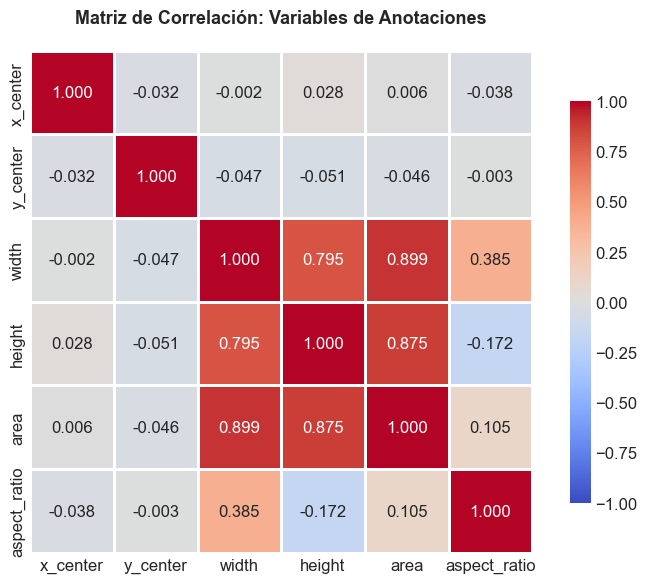


🔍 Correlaciones más fuertes con 'area':
area            1.0000
width           0.8990
height          0.8750
aspect_ratio    0.1050
x_center        0.0060
y_center       -0.0460
Name: area, dtype: float64


In [17]:
# Matriz de correlación de variables geométricas
numeric_vars = ['x_center', 'y_center', 'width', 'height', 'area', 'aspect_ratio']
corr_matrix = df[numeric_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlación: Variables de Anotaciones', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🔍 Correlaciones más fuertes con 'area':")
print(corr_matrix['area'].sort_values(ascending=False).round(3))

### 8.6. Imágenes de Muestra con Anotaciones

Visualización de imágenes reales del dataset con sus bounding boxes superpuestos.

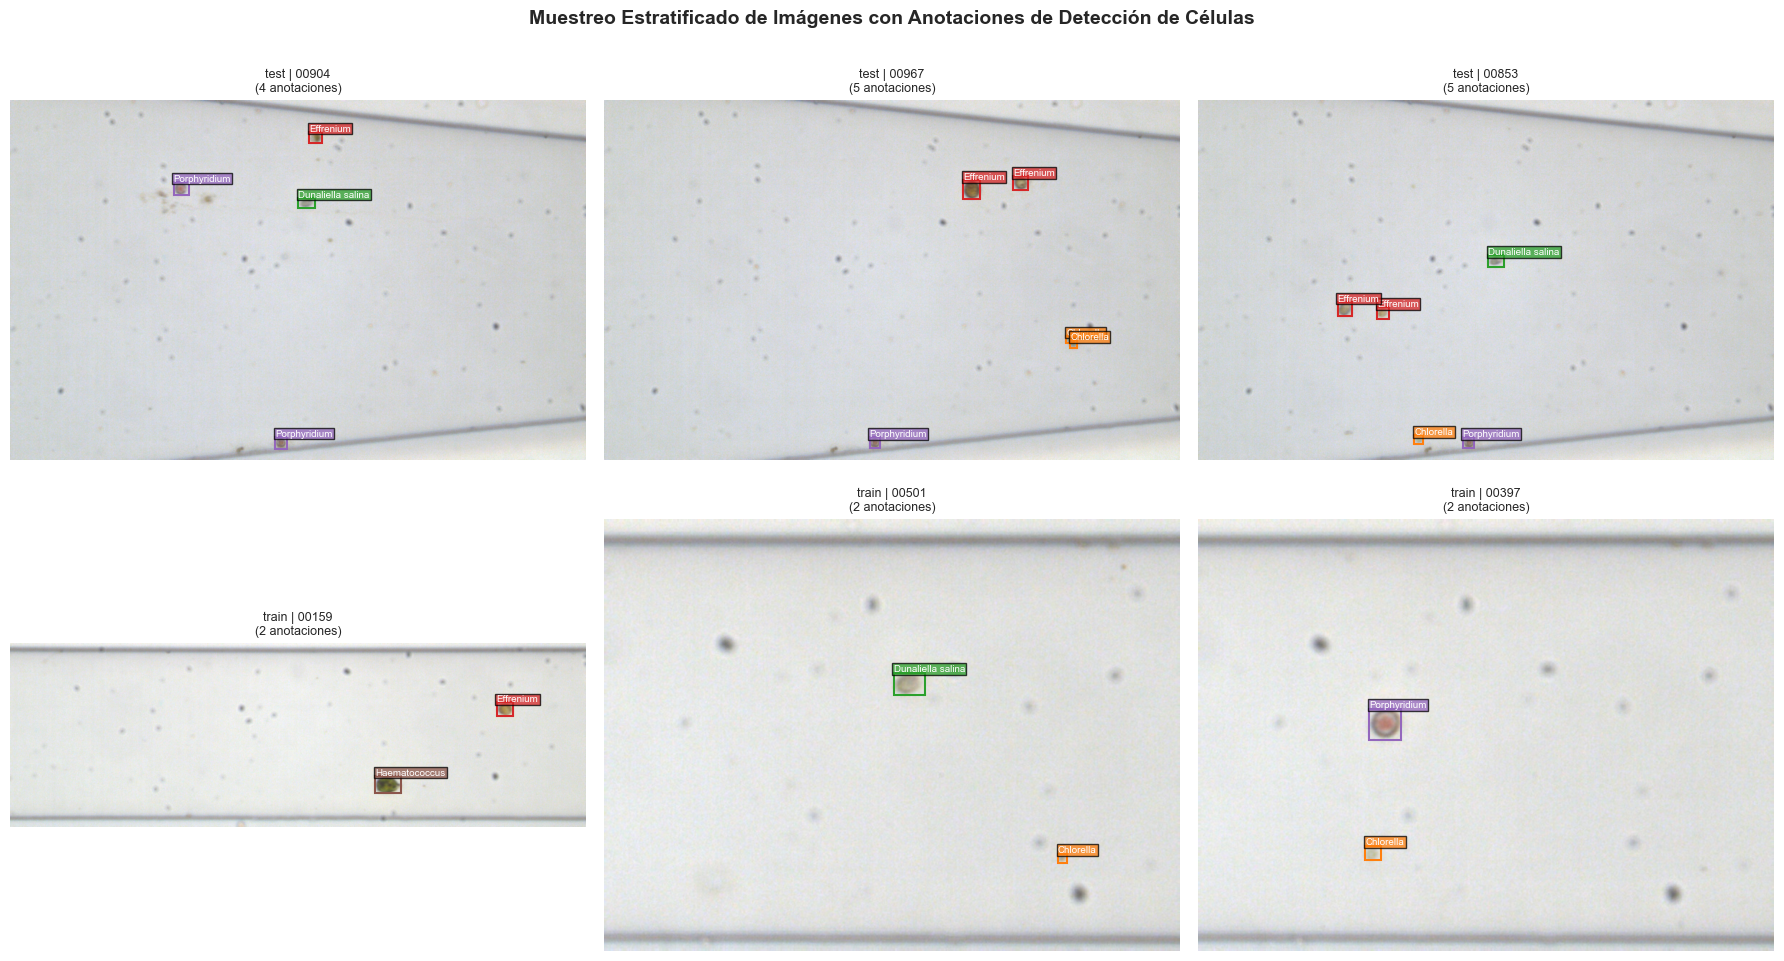


🧪 Muestreo de visualización por split:
split
test     3
train    3


In [18]:
def get_bbox_color(class_id, n_classes):
    """Retorna un color RGB para cada clase."""
    cmap = plt.cm.get_cmap('tab10', max(n_classes, 10))
    return cmap(class_id % max(n_classes, 10))[:3]

# Muestreo estratificado por split para visualización representativa
samples_per_split = 3
sample_rows = []

for split in sorted(df['split'].unique()):
    split_files = (
        df[df['split'] == split][['split', 'filename']]
        .drop_duplicates()
        .sample(min(samples_per_split, df[df['split'] == split]['filename'].nunique()), random_state=42)
    )
    sample_rows.append(split_files)

sample_df = pd.concat(sample_rows, ignore_index=True) if sample_rows else pd.DataFrame(columns=['split', 'filename'])

n_samples = len(sample_df)
if n_samples == 0:
    print("⚠️ No hay muestras disponibles para visualizar.")
else:
    n_cols = 3
    n_rows = int(np.ceil(n_samples / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, row in sample_df.iterrows():
        ax = axes[idx]
        split = row['split']
        filename = row['filename']

        img_dir = split_paths[split]['images']
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']:
            p = img_dir / f"{filename}{ext}"
            if p.exists():
                img_path = p
                break

        if img_path and img_path.exists():
            img = Image.open(img_path).convert('RGB')
            img_w, img_h = img.size
            ax.imshow(img)

            # Dibujar bounding boxes SOLO del split/archivo actual
            file_anns = df[(df['split'] == split) & (df['filename'] == filename)]
            n_classes_total = df['class_id'].nunique()
            for _, ann in file_anns.iterrows():
                x_c, y_c, w, h = ann['x_center'], ann['y_center'], ann['width'], ann['height']
                x1 = (x_c - w / 2) * img_w
                y1 = (y_c - h / 2) * img_h
                box_w = w * img_w
                box_h = h * img_h
                color = get_bbox_color(ann['class_id'], n_classes_total)

                rect = patches.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=1.5, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(
                    x1, y1 - 2, ann['class_name'], fontsize=7, color='white',
                    bbox=dict(facecolor=color, alpha=0.75, pad=1)
                )

            ax.set_title(f"{split} | {filename[:25]}\n({len(file_anns)} anotaciones)", fontsize=9)
        else:
            ax.set_title(f"{split} | {filename[:25]}\n(imagen no disponible)", fontsize=9)
            ax.text(
                0.5, 0.5, 'Imagen\nno disponible',
                ha='center', va='center', transform=ax.transAxes, fontsize=12
            )

        ax.axis('off')

    for j in range(n_samples, len(axes)):
        axes[j].axis('off')

    plt.suptitle(
        'Muestreo Estratificado de Imágenes con Anotaciones de Detección de Células',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print("\n🧪 Muestreo de visualización por split:")
    print(sample_df['split'].value_counts().to_string())